# Experiments to evaluate autoscaling cost

In [1]:
# Basic imports and method to write autoscaling results
import numpy as np
from numpy import percentile as percentile
import pandas as pd
from ascal import AscalConfig, Ascal
from examples import aws_eu_west_1_c5m5r5
import os

def plot_ascal_results(ascal_problem: Ascal):
    # Get application overloads as workload/performance
    workloads = ascal_problem.get_workloads()
    performances = ascal_problem.get_performances()
    overloads = {app: [(w-p)/w for w, p in zip(workloads[app], performances[app])] for app in workloads}

    # Get queue waiting times relative to service times, assuming each container is a server in a 
    # heterogenous D/D/n queue
    relative_queue_waiting_times = ascal_problem.get_relative_queue_waiting_times()
    percentiles99 = {
        app_name: percentile(waiting_times, 99)
        for app_name, waiting_times in relative_queue_waiting_times.items()
    }
    for app_name in dict(relative_queue_waiting_times):
        relative_queue_waiting_times[f"{app_name} 99% percentile = {percentiles99[app_name]:.3f}"] =\
            relative_queue_waiting_times.pop(app_name)
    # Plot autoscaling information
    ascal_problem.plot(ascal_problem.get_performances(), "Application Performances", "req/s")
    cluster_cost = ascal_problem.get_cluster_cost()
    total_cost_str = f"total cost = {sum(cluster_cost)/3600:.3f} $"
    ascal_problem.plot({total_cost_str: cluster_cost}, "Cluster Cost", "$/hour")
    ascal_problem.plot(overloads, "Application Overloads")
    ascal_problem.plot(relative_queue_waiting_times, "Relative queue waiting times")

## Generate the trace files
The trace file has 3600 samples. Note that the number of samples can be multiplied using `time_interval` field in 
ASCAL configuration files.

In [2]:
num_samples = 3600

# Generate a trapezoidal waveform with random noise and save it to a CSV file
min_val = 10
max_val = 100
noise_amplitude = 0.1

# Generate complete trapezoidal waveform (ramp up, plateau, ramp down)
ramp_len = (num_samples - 1800) // 2
ramp_up = np.linspace(min_val, max_val, ramp_len)
plateau = np.full(1800, max_val)
ramp_down = np.linspace(max_val, min_val, ramp_len)
trapezoid = np.concatenate([ramp_up, plateau, ramp_down])
trapezoid = trapezoid[:num_samples]

# Add random noise
noise = np.random.normal(0, noise_amplitude * (trapezoid + 20))
trapezoid_noisy = trapezoid + noise
trapezoid_noisy = np.round(trapezoid_noisy).astype(int)

# Create DataFrame and save to CSV
df_triangle = pd.DataFrame({'requests/s': trapezoid_noisy})
df_triangle.to_csv('trapezoid.csv', index=False)

## HPA+CA autoscaling

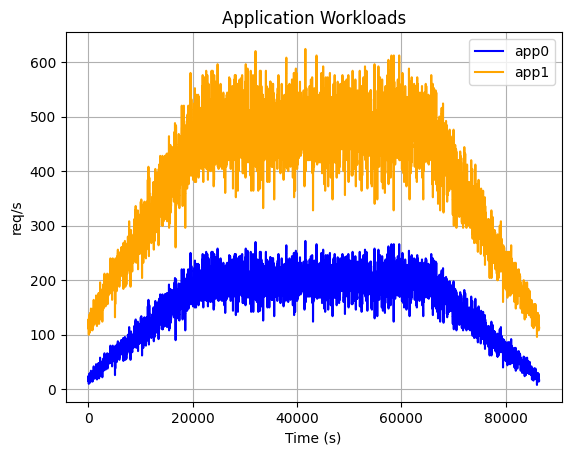

In [3]:
# Set experiment
config_file = "exp-hpa-ca.yaml"
ascal_config = AscalConfig.get_from_config_yaml(config_file, aws_eu_west_1_c5m5r5.c5_m5_r5_fm)
ascal_problem = Ascal(ascal_config) 
ascal_problem.plot(ascal_problem.get_workloads(), "Application Workloads", "req/s")

In [4]:
# Run experiment
ascal_problem.run()

Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
Time: 2500 s
Time: 2600 s
Time: 2700 s
Time: 2800 s
Time: 2900 s
Time: 3000 s
Time: 3100 s
Time: 3200 s
Time: 3300 s
Time: 3400 s
Time: 3500 s
Time: 3600 s
Time: 3700 s
Time: 3800 s
Time: 3900 s
Time: 4000 s
Time: 4100 s
Time: 4200 s
Time: 4300 s
Time: 4400 s
Time: 4500 s
Time: 4600 s
Time: 4700 s
Time: 4800 s
Time: 4900 s
Time: 5000 s
Time: 5100 s
Time: 5200 s
Time: 5300 s
Time: 5400 s
Time: 5500 s
Time: 5600 s
Time: 5700 s
Time: 5800 s
Time: 5900 s
Time: 6000 s
Time: 6100 s
Time: 6200 s
Time: 6300 s
Time: 6400 s
Time: 6500 s
Time: 6600 s
Time: 6700 s
Time: 6800 s
Time: 6900 s
Time: 7000 s
Time: 7100 s
Time: 7200 s
Time: 7300 s
Time: 7400 s
Time: 7500 s
Time: 7600 s
Time: 7700 

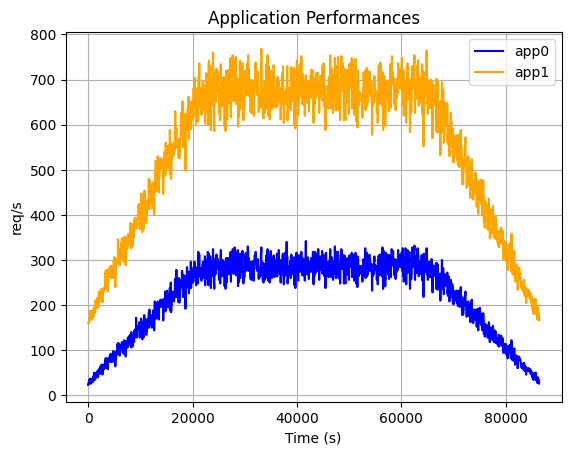

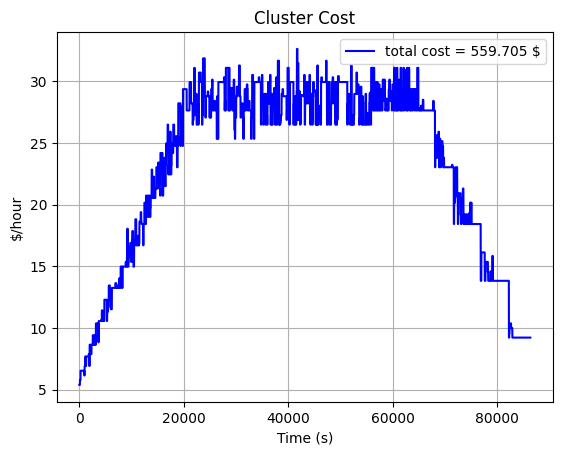

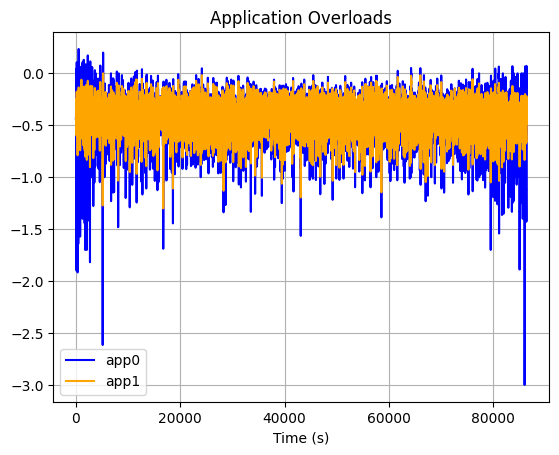

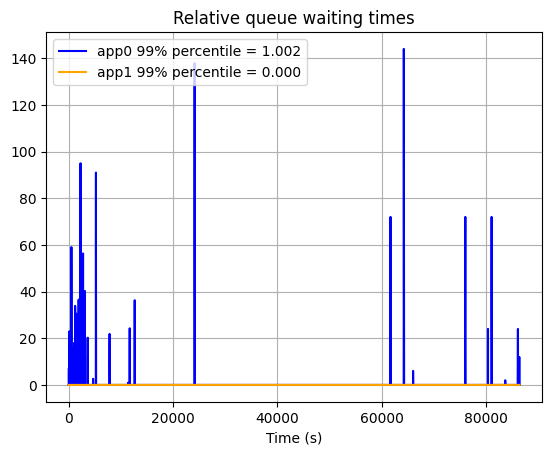

In [5]:
# Plot results
plot_ascal_results(ascal_problem)

## HV Reactive autoscaling with FCMA

In [8]:
# Set experiment
config_file = "exp-hv-reactive-fcma.yaml"
ascal_config = AscalConfig.get_from_config_yaml(config_file, aws_eu_west_1_c5m5r5.c5_m5_r5_fm)
ascal_problem = Ascal(ascal_config)

In [12]:
# Run experiment
ascal_problem.run()

In [ ]:
# Plot results
plot_ascal_results(ascal_problem)

## HV Predictive autoscaling with FCMA

In [ ]:
# Set experiment
config_file = "exp-hv-predictive-fcma.yaml"
ascal_config = AscalConfig.get_from_config_yaml(config_file, aws_eu_west_1_c5m5r5.c5_m5_r5_fm)
ascal_problem = Ascal(ascal_config)

In [10]:
# Run experiment
ascal_problem.run()

You can check the CBC log at /tmp/f392dba7c44b4036b3d102d1eff4603a-pulp.lp.log
You can check the CBC log at /tmp/2bbdf10e504e47aeb9964dc6a33d3d40-pulp.lp.log
Time: 62800 s
You can check the CBC log at /tmp/c2fa8b332e6e48edbc3d1cffa41dbfa1-pulp.lp.log
You can check the CBC log at /tmp/57a19004bef34bfe9f97049850339fc3-pulp.lp.log
Time: 62900 s
Time: 63000 s
You can check the CBC log at /tmp/f2b9f78ada71456e9405d865eebdedf6-pulp.lp.log
You can check the CBC log at /tmp/b0641e60e32748f3b8c1178ec50a262b-pulp.lp.log
Time: 63100 s
You can check the CBC log at /tmp/b39a5d2c5e9247fb9543e8db7aa64a4e-pulp.lp.log
You can check the CBC log at /tmp/9fb3e1f746ce4178944771899d9e72f9-pulp.lp.log
Time: 63200 s
Time: 63300 s
You can check the CBC log at /tmp/73ab9c6b05184ef5bf712d2596ba0622-pulp.lp.log
You can check the CBC log at /tmp/40dc7553ce684643b452fc76a459cc25-pulp.lp.log
Time: 63400 s
You can check the CBC log at /tmp/07da806fe5214d158568a46fca3badc4-pulp.lp.log
You can check the CBC log at /tmp

In [ ]:
# Plot results
plot_ascal_results(ascal_problem)